
Loading FPGA
Overlay loaded

IP blocks:
  axi_dma_0
  ps7_0

DMA:


/usr/local/share/pynq-venv/lib/python3.8/site-packages/pynq/overlay.py:681: UserWarning: Interrupt s2mm_introut not created: Could not find UIO device for interrupt pin for IRQ number 62
  warnings.warn('Interrupt {} not created: {}'.format(



DMA buffer configuration
------------------------
Input samples : 81920
Output samples: 2048
chunk 0: input= 81920 output= 2048
chunk 1: input= 81920 output= 2048
chunk 2: input= 81920 output= 2048
chunk 3: input= 81920 output= 2048
chunk 4: input= 81920 output= 2048
chunk 5: input= 81920 output= 2048
chunk 6: input= 81920 output= 2048
chunk 7: input= 81920 output= 2048
chunk 8: input= 81920 output= 2048
chunk 9: input= 81920 output= 2048
chunk 10: input= 81920 output= 2048
chunk 11: input= 81920 output= 2048
chunk 12: input= 81920 output= 2048
chunk 13: input= 81920 output= 2048
chunk 14: input= 81920 output= 2048
chunk 15: input= 81920 output= 2048
chunk 16: input= 81920 output= 2048
chunk 17: input= 81920 output= 2048
chunk 18: input= 81920 output= 2048
chunk 19: input= 81920 output= 2048
chunk 20: input= 81920 output= 2048
chunk 21: input= 81920 output= 2048
chunk 22: input= 81920 output= 2048
chunk 23: input= 81920 output= 2048
chunk 24: input= 81920 output= 2048
chunk 25: input=

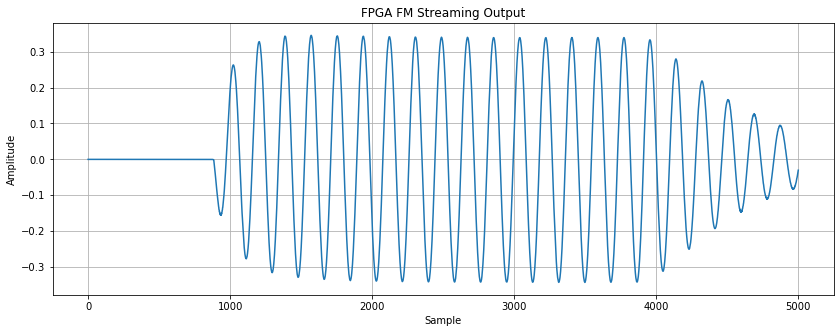

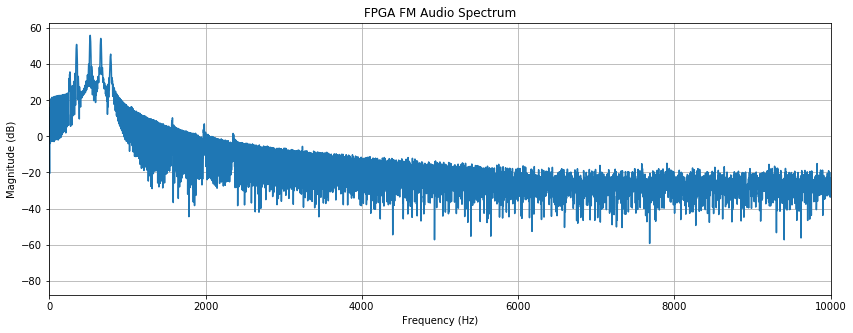


Done.


In [1]:
import numpy as np

from pynq import Overlay, allocate


# ============================================================
# Configuration
# ============================================================

# BIT_FILE = "./../vivado/pynq_fm.bit"
BIT_FILE = "./../hong/base.bit"

INPUT_FILE = "fm_data.txt"


# ============================================================
# FPGA pipeline
#
# 1.92 MHz
#      |
#      v
#   FIR / 5
#      |
#      v
#    FM demod
#      |
#      v
#   decimation
#      |
#      v
#    48 kHz
#
# Overall:
#
#       1,920,000 / 48,000 = 40
#
# ============================================================

DECIMATION = 40


# ============================================================
# DMA chunk
#
# MUST be divisible by 40
#
# 40 * 2048 = 81920
#
# Output:
#
# 81920 / 40 = 2048
#
# ============================================================

CHUNK_SIZE = 40 * 2048

OUTPUT_SIZE = CHUNK_SIZE // DECIMATION


# ============================================================
# Load overlay
# ============================================================

print()
print("============================================================")
print("Loading FPGA")
print("============================================================")

ol = Overlay(
    BIT_FILE
)

print("Overlay loaded")


# ============================================================
# Show IP
# ============================================================

print()
print("IP blocks:")

for name in ol.ip_dict.keys():
    print(
        " ",
        name
    )


# ============================================================
# Get DMA
# ============================================================

dma = ol.axi_dma_0

print()
print("DMA:")
print(dma)


# ============================================================
# Allocate DMA buffers
# ============================================================

input_buffer = allocate(
    shape=(CHUNK_SIZE,),
    dtype=np.uint16
)

output_buffer = allocate(
    shape=(OUTPUT_SIZE,),
    dtype=np.int16
)


print()
print("DMA buffer configuration")
print("------------------------")
print("Input samples :", CHUNK_SIZE)
print("Output samples:", OUTPUT_SIZE)


# ============================================================
# Read one chunk from TXT
# ============================================================

def read_chunk(file_handle):

    data = []

    while len(data) < CHUNK_SIZE:

        line = file_handle.readline()

        if not line:
            break

        line = line.strip()

        if not line:
            continue

        if line.startswith("#"):
            continue

        data.append(
            int(line)
        )

    return np.asarray(
        data,
        dtype=np.uint16
    )


# ============================================================
# Main streaming
# ============================================================

total_input = 0
total_output = 0

audio_chunks = []

chunk_number = 0


with open(
    INPUT_FILE,
    "r"
) as f:

    while True:

        # ====================================================
        # Read chunk
        # ====================================================

        data = read_chunk(
            f
        )

        if len(data) == 0:
            break


        # ====================================================
        # Last chunk
        #
        # FPGA requires complete groups of 40.
        #
        # Ignore incomplete tail.
        # ====================================================

        valid_input = (
            len(data) // DECIMATION
        ) * DECIMATION


        if valid_input == 0:

            print(
                "Ignoring final incomplete chunk"
            )

            break


        if valid_input != len(data):

            print(
                "Trimming final chunk:",
                len(data),
                "->",
                valid_input
            )

            data = data[
                :valid_input
            ]


        output_count = (
            len(data)
            // DECIMATION
        )


        # ====================================================
        # Copy input into DMA buffer
        # ====================================================

        input_buffer[
            :len(data)
        ] = data


        # ====================================================
        # Clear output buffer
        #
        # Useful for debugging
        # ====================================================

        output_buffer[
            :output_count
        ].fill(0)


        # ====================================================
        # DMA
        #
        # IMPORTANT:
        #
        # S2MM first
        # MM2S second
        #
        # So the receiver is ready before data is sent.
        # ====================================================

        dma.recvchannel.transfer(
            output_buffer[
                :output_count
            ]
        )

        dma.sendchannel.transfer(
            input_buffer[
                :len(data)
            ]
        )


        # ====================================================
        # Wait
        # ====================================================

        dma.sendchannel.wait()

        dma.recvchannel.wait()


        # ====================================================
        # Copy output
        #
        # Must copy because output_buffer is reused.
        # ====================================================

        chunk_audio = np.array(
            output_buffer[
                :output_count
            ],
            dtype=np.int16
        )


        audio_chunks.append(
            chunk_audio
        )


        # ====================================================
        # Statistics
        # ====================================================

        total_input += len(data)

        total_output += output_count


        print(
            f"chunk {chunk_number}: "
            f"input={len(data):6d} "
            f"output={output_count:5d}"
        )


        chunk_number += 1


# ============================================================
# Combine audio
# ============================================================

if len(audio_chunks) == 0:

    raise RuntimeError(
        "No audio output was received"
    )


audio = np.concatenate(
    audio_chunks
)


# ============================================================
# Convert to float
# ============================================================

audio_float = (
    audio.astype(np.float32)
    / 32768.0
)


# ============================================================
# Statistics
# ============================================================

print()
print("============================================================")
print("Streaming complete")
print("============================================================")

print(
    "Input samples :",
    total_input
)

print(
    "Output samples:",
    total_output
)

print(
    "Duration      :",
    f"{total_output / 48000:.3f} sec"
)

print(
    "Min           :",
    np.min(audio)
)

print(
    "Max           :",
    np.max(audio)
)


# ============================================================
# Save raw output
# ============================================================

np.save(
    "fpga_stream_output.npy",
    audio
)


# ============================================================
# Plot waveform
# ============================================================

import matplotlib.pyplot as plt


plt.figure(
    figsize=(14, 5)
)

plot_samples = min(
    5000,
    len(audio_float)
)

plt.plot(
    audio_float[:plot_samples]
)

plt.title(
    "FPGA FM Streaming Output"
)

plt.xlabel(
    "Sample"
)

plt.ylabel(
    "Amplitude"
)

plt.grid()

plt.show()


# ============================================================
# FFT
# ============================================================

fft_len = min(
    len(audio_float),
    32768
)


if fft_len > 0:

    x = audio_float[
        :fft_len
    ]

    window = np.hanning(
        fft_len
    )

    spectrum = np.fft.rfft(
        x * window
    )

    freq = np.fft.rfftfreq(
        fft_len,
        1 / 48000
    )

    spectrum_db = (
        20
        * np.log10(
            np.abs(spectrum)
            + 1e-12
        )
    )


    plt.figure(
        figsize=(14, 5)
    )

    plt.plot(
        freq,
        spectrum_db
    )

    plt.xlim(
        0,
        10000
    )

    plt.title(
        "FPGA FM Audio Spectrum"
    )

    plt.xlabel(
        "Frequency (Hz)"
    )

    plt.ylabel(
        "Magnitude (dB)"
    )

    plt.grid()

    plt.show()


# ============================================================
# Play audio
# ============================================================

from IPython.display import Audio, display


display(
    Audio(
        audio_float,
        rate=48000,
        autoplay=False
    )
)


# ============================================================
# Cleanup
# ============================================================

del input_buffer
del output_buffer

print()
print("Done.")